# Phase 3 : EDA and statistical analysisi

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working folder:", os.getcwd())

sns.set_theme(style='whitegrid')

# Keep the same mood colors in every Moodwave chart.
mood_order = ['Euphoric', 'Peaceful', 'Aggressive', 'Melancholic']
mood_colors = {
    'Euphoric': '#F4C95D',
    'Peaceful': '#67C6C3',
    'Aggressive': '#E85D5D',
    'Melancholic': '#6C70B5'
}

os.makedirs('reports/figures/03_eda', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)
os.makedirs('reports/eda', exist_ok=True)

Working folder: C:\dev\Moodwave\moodwave-ml


## 1. Load the Phase 2 datasets

In [2]:
# Use Parquet when available. The compressed CSV files are a fallback.
if os.path.exists('data/processed/historical_tracks.parquet'):
    historical = pd.read_parquet('data/processed/historical_tracks.parquet')
    genre = pd.read_parquet('data/processed/genre_tracks.parquet')
    country = pd.read_parquet('data/processed/country_chart_observations.parquet')
else:
    historical = pd.read_csv('data/processed/historical_tracks.csv.gz')
    genre = pd.read_csv('data/processed/genre_tracks.csv.gz')
    country = pd.read_csv('data/processed/country_chart_observations.csv.gz')

country['snapshot_date'] = pd.to_datetime(country['snapshot_date'], errors='coerce')

print('Historical:', historical.shape)
print('Genre:', genre.shape)
print('Country:', country.shape)
print('Genres available:', genre['track_genre'].nunique())
print('Chart scopes available:', country['country'].nunique())

Historical: (2400, 28)
Genre: (113550, 27)
Country: (2110316, 32)
Genres available: 114
Chart scopes available: 73


In [3]:
historical.head()

,playlist_url,year,track_id,track_name,popularity,album_name,artist_id,artist_name,artist_genres,artist_popularity,...,liveness,valence,tempo,duration_ms,time_signature,mood_label,mood_valence_band,mood_energy_band,duration_min,release_decade
0,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,6naxalmIoLFWR0siv8dnQQ,Oops!...I Did It Again,81,Oops!... I Did It Again,26dSoYclwsYLMAKD3tpOr4,Britney Spears,"['dance pop', 'pop']",81,...,0.3550,0.894,95.053,211160,4,Euphoric,high,high,3.519333,2000
1,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,2m1hi0nfMR9vdGC8UcrnwU,All The Small Things,83,Enema Of The State,6FBDaR13swtiWwGhX1WQsP,blink-182,"['alternative metal', 'modern rock', 'pop punk...",79,...,0.6120,0.684,148.726,167067,4,Euphoric,high,high,2.784450,2000
2,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,3y4LxiYMgDl4RethdzpmNe,Breathe,66,Breathe,25NQNriVT2YbSW80ILRWJa,Faith Hill,"['contemporary country', 'country', 'country d...",62,...,0.2510,0.278,136.859,250547,4,Melancholic,low,low,4.175783,2000
3,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,0v1XpBHnsbkCn7iJ9Ucr1l,It's My Life,81,Crush,58lV9VcRSjABbAbfWS6skp,Bon Jovi,"['glam metal', 'rock']",79,...,0.3470,0.544,119.992,224493,4,Euphoric,high,high,3.741550,2000
4,https://open.spotify.com/playlist/37i9dQZF1DWU...,2000,62bOmKYxYg7dhrC6gH9vFn,Bye Bye Bye,75,No Strings Attached,6Ff53KvcvAj5U7Z1vojB5o,*NSYNC,"['boy band', 'dance pop', 'pop']",70,...,0.0821,0.861,172.638,200400,4,Euphoric,high,high,3.340000,2000


## 2. Descriptive statistics

We calculate the main statistics for all three datasets rather than only one of them. This gives us a broader view before making any models.

In [4]:
numeric_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_min', 'popularity'
]

all_stats = []

for dataset_name, df in [
    ('historical', historical),
    ('genre', genre),
    ('country', country)
]:
    stats = df[numeric_features].describe().T
    stats['median'] = df[numeric_features].median()
    stats['variance'] = df[numeric_features].var()
    stats['dataset'] = dataset_name
    stats['feature'] = stats.index
    all_stats.append(stats.reset_index(drop=True))

descriptive_stats = pd.concat(all_stats, ignore_index=True)

descriptive_stats = descriptive_stats[[
    'dataset', 'feature', 'count', 'mean', 'median', 'std',
    'variance', 'min', '25%', '50%', '75%', 'max'
]]

descriptive_stats.head(15)

,dataset,feature,count,mean,median,std,variance,min,25%,50%,75%,max
0,historical,danceability,2400.0,0.661767,0.673000,0.140335,0.019694,0.162000,0.573750,0.673000,0.760000,0.975000
1,historical,energy,2400.0,0.688705,0.706000,0.165345,0.027339,0.051900,0.585000,0.706000,0.814000,0.999000
2,historical,loudness,2400.0,-5.811735,-5.526500,2.086712,4.354367,-21.107000,-6.846000,-5.526500,-4.381750,-0.276000
3,historical,speechiness,2400.0,0.097995,0.056800,0.093276,0.008700,0.022500,0.037900,0.056800,0.115000,0.576000
4,historical,acousticness,2400.0,0.164838,0.073600,0.210630,0.044365,0.000013,0.018075,0.073600,0.233000,0.978000
5,historical,instrumentalness,2400.0,0.013442,0.000000,0.082364,0.006784,0.000000,0.000000,0.000000,0.000057,0.985000
6,historical,liveness,2400.0,0.174978,0.120500,0.134153,0.017997,0.021000,0.090475,0.120500,0.225000,0.979000
7,historical,valence,2400.0,0.536023,0.544000,0.228995,0.052439,0.037700,0.359750,0.544000,0.726000,0.974000
8,historical,tempo,2400.0,120.456363,120.000000,27.640203,763.980835,60.019000,98.061500,120.000000,137.644500,210.857000
9,historical,duration_min,2400.0,3.744926,3.682558,0.694216,0.481935,1.623217,3.317508,3.682558,4.091117,10.217117


In [5]:
print('Historical mood distribution (%):')
print((historical['mood_label'].value_counts(normalize=True) * 100).round(2))

print()
print('Genre rows by mood (%):')
print((genre['mood_label'].value_counts(normalize=True) * 100).round(2))

Historical mood distribution (%):
mood_label
Euphoric       52.46
Aggressive     33.96
Melancholic    10.04
Peaceful        3.54
Name: proportion, dtype: float64

Genre rows by mood (%):
mood_label
Euphoric       38.13
Aggressive     34.05
Melancholic    20.18
Peaceful        7.64
Name: proportion, dtype: float64


## 3. Emotion quadrant - valence vs energy

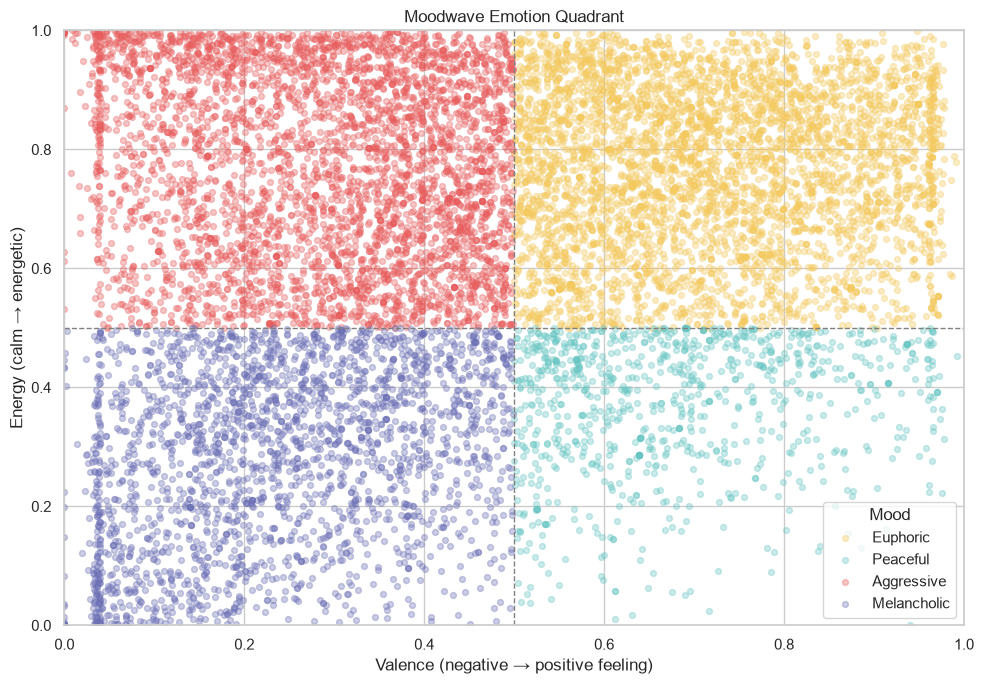

In [6]:
# Sample the large genre dataset so the scatter plot stays readable.
plot_sample = genre.sample(n=min(12000, len(genre)), random_state=42)

plt.figure(figsize=(10, 7))

for mood in mood_order:
    part = plot_sample[plot_sample['mood_label'] == mood]
    plt.scatter(
        part['valence'],
        part['energy'],
        s=18,
        alpha=0.35,
        label=mood,
        color=mood_colors[mood]
    )

plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Moodwave Emotion Quadrant')
plt.xlabel('Valence (negative → positive feeling)')
plt.ylabel('Energy (calm → energetic)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title='Mood')
plt.tight_layout()
plt.savefig('reports/figures/03_eda/emotion_quadrant.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/emotion_quadrant.svg', bbox_inches='tight')
plt.show()

The quadrant uses the same valence and energy boundaries defined in Phase 2. It gives a direct visual picture of the four emotional regions instead of treating mood as an unexplained label.

## 4. Historical audio trends from 2000 to 2023

In [7]:
yearly_trends = historical.groupby('year')[[
    'valence', 'energy', 'danceability', 'popularity'
]].mean().reset_index()

yearly_trends.head()

,year,valence,energy,danceability,popularity
0,2000,0.628990,0.749500,0.65875,65.66
1,2001,0.653694,0.720960,0.67281,66.79
2,2002,0.574905,0.729480,0.65076,64.64
3,2003,0.600036,0.705130,0.66311,66.25
4,2004,0.598722,0.712545,0.66997,67.68


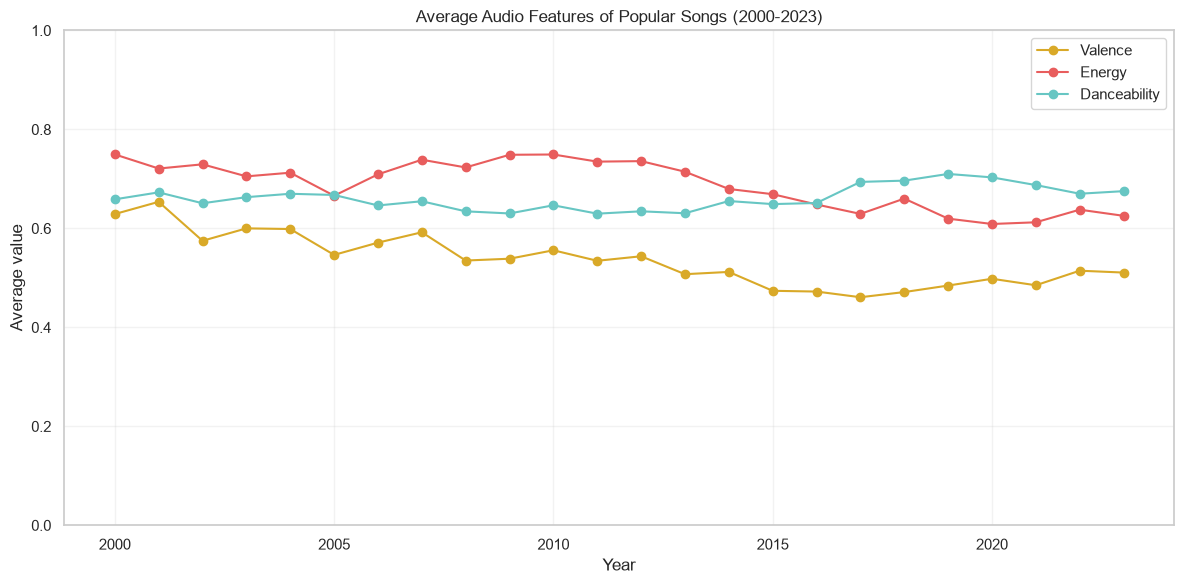

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(yearly_trends['year'], yearly_trends['valence'], marker='o', label='Valence', color='#D9A928')
plt.plot(yearly_trends['year'], yearly_trends['energy'], marker='o', label='Energy', color='#E85D5D')
plt.plot(yearly_trends['year'], yearly_trends['danceability'], marker='o', label='Danceability', color='#67C6C3')

plt.title('Average Audio Features of Popular Songs (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Average value')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('reports/figures/03_eda/yearly_valence_energy.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/yearly_valence_energy.svg', bbox_inches='tight')
plt.show()

In [9]:
print('Highest average valence year:')
print(yearly_trends.loc[yearly_trends['valence'].idxmax(), ['year', 'valence']])

print()
print('Lowest average valence year:')
print(yearly_trends.loc[yearly_trends['valence'].idxmin(), ['year', 'valence']])

print()
print('Highest average energy year:')
print(yearly_trends.loc[yearly_trends['energy'].idxmax(), ['year', 'energy']])

print()
print('Lowest average energy year:')
print(yearly_trends.loc[yearly_trends['energy'].idxmin(), ['year', 'energy']])

Highest average valence year:
year       2001.000000
valence       0.653694
Name: 1, dtype: float64

Lowest average valence year:
year       2017.000000
valence       0.460871
Name: 17, dtype: float64

Highest average energy year:
year      2000.0000
energy       0.7495
Name: 0, dtype: float64

Lowest average energy year:
year      2020.0000
energy       0.6089
Name: 20, dtype: float64


## 5. Mood composition by year

In [10]:
yearly_moods = pd.crosstab(
    historical['year'],
    historical['mood_label'],
    normalize='index'
) * 100

yearly_moods = yearly_moods.reindex(columns=mood_order, fill_value=0)
yearly_moods.head()

mood_label,Euphoric,Peaceful,Aggressive,Melancholic
year,,,,
2000,71.0,5.0,18.0,6.0
2001,76.0,3.0,14.0,7.0
2002,59.0,2.0,36.0,3.0
2003,66.0,5.0,22.0,7.0
2004,60.0,8.0,25.0,7.0


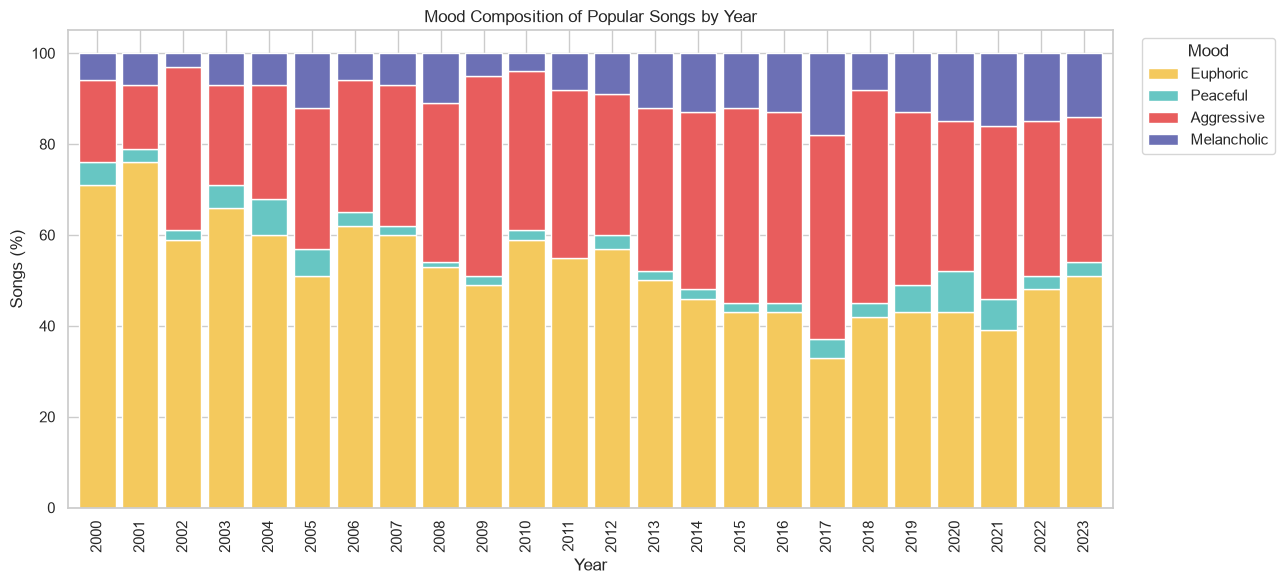

In [11]:
yearly_moods.plot(
    kind='bar',
    stacked=True,
    figsize=(13, 6),
    color=[mood_colors[mood] for mood in mood_order],
    width=0.85
)

plt.title('Mood Composition of Popular Songs by Year')
plt.xlabel('Year')
plt.ylabel('Songs (%)')
plt.legend(title='Mood', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('reports/figures/03_eda/yearly_mood_composition.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/yearly_mood_composition.svg', bbox_inches='tight')
plt.show()

## 6. Correlation between audio features and popularity

In [12]:
corr_columns = [
    'popularity', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_min'
]

correlation = genre[corr_columns].corr()
correlation

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,0.034412,-0.002444,0.047371,-0.045459,-0.022370,-0.094711,-0.005658,-0.041109,0.012180,-0.007899
danceability,0.034412,1.000000,0.131695,0.256559,0.108237,-0.169183,-0.183972,-0.131648,0.476750,-0.051518,-0.074108
energy,-0.002444,0.131695,1.000000,0.760625,0.141976,-0.732745,-0.179966,0.184812,0.258448,0.247360,0.058163
loudness,0.047371,0.256559,0.760625,1.000000,0.060088,-0.588110,-0.432108,0.076793,0.279424,0.212180,-0.004228
speechiness,-0.045459,0.108237,0.141976,0.060088,1.000000,-0.001381,-0.089213,0.205092,0.036391,0.017166,-0.063188
acousticness,-0.022370,-0.169183,-0.732745,-0.588110,-0.001381,1.000000,0.102129,-0.020321,-0.106228,-0.207613,-0.103695
instrumentalness,-0.094711,-0.183972,-0.179966,-0.432108,-0.089213,0.102129,1.000000,-0.079843,-0.324316,-0.049941,0.125307
liveness,-0.005658,-0.131648,0.184812,0.076793,0.205092,-0.020321,-0.079843,1.000000,0.019332,0.000543,0.010213
valence,-0.041109,0.476750,0.258448,0.279424,0.036391,-0.106228,-0.324316,0.019332,1.000000,0.077644,-0.154810
tempo,0.012180,-0.051518,0.247360,0.212180,0.017166,-0.207613,-0.049941,0.000543,0.077644,1.000000,0.024301


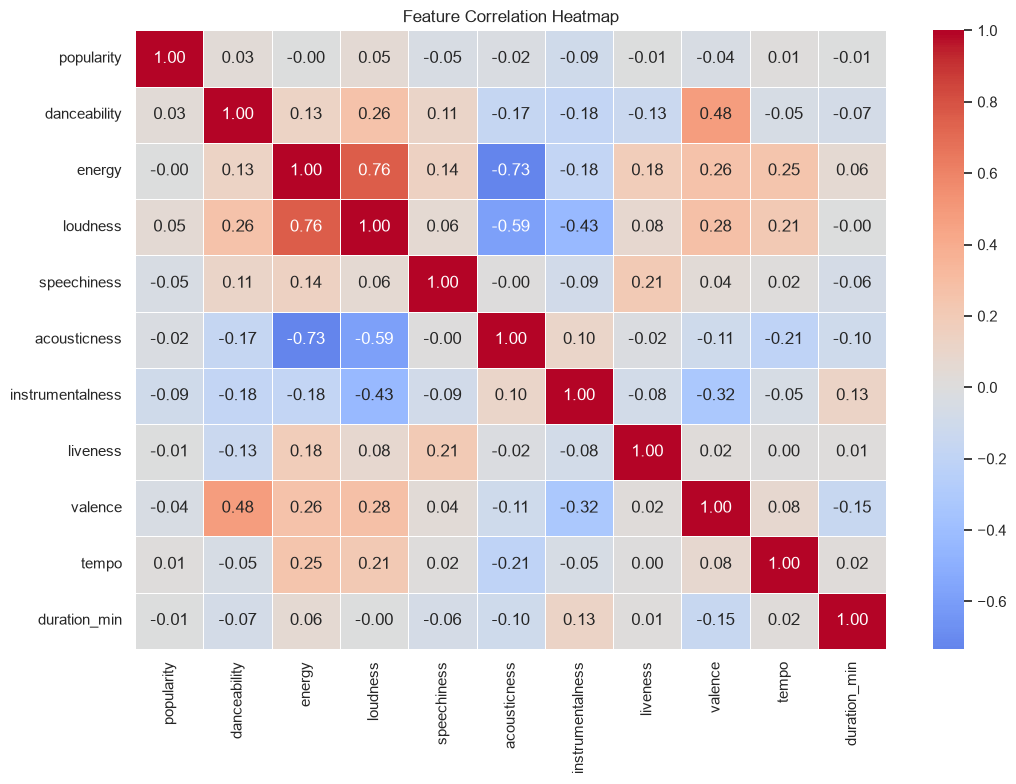

In [13]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('reports/figures/03_eda/feature_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/feature_correlation_heatmap.svg', bbox_inches='tight')
plt.show()

In [14]:
print('Correlation with popularity:')
print(
    correlation['popularity']
    .drop('popularity')
    .sort_values(key=abs, ascending=False)
)

Correlation with popularity:
instrumentalness   -0.094711
loudness            0.047371
speechiness        -0.045459
valence            -0.041109
danceability        0.034412
acousticness       -0.022370
tempo               0.012180
duration_min       -0.007899
liveness           -0.005658
energy             -0.002444
Name: popularity, dtype: float64


The individual audio features have weak linear relationships with popularity. This is useful to know before regression because popularity is also influenced by artist exposure, marketing, release timing and other factors that are not present in these datasets.

## 7. Compare selected genres

The summary tables still contain **all 114 genres**. For visual comparisons we use eight varied genres so the graphs remain readable while still showing a broad musical range.

In [15]:
selected_genres = [
    'pop', 'rock', 'hip-hop', 'jazz',
    'classical', 'country', 'edm', 'acoustic'
]

selected = genre[genre['track_genre'].isin(selected_genres)].copy()

# Keep a stable color for each selected genre.
genre_colors = {
    'pop': '#DDB892',
    'rock': '#A9A9A9',
    'hip-hop': '#A6C96A',
    'jazz': '#F2D34F',
    'classical': '#E99069',
    'country': '#8FA2C4',
    'edm': '#CF91B9',
    'acoustic': '#78B7A5'
}

print('Selected genres:', selected_genres)
print()
print('Rows available for each genre:')
print(selected['track_genre'].value_counts().reindex(selected_genres))

Selected genres: ['pop', 'rock', 'hip-hop', 'jazz', 'classical', 'country', 'edm', 'acoustic']

Rows available for each genre:
track_genre
pop           993
rock         1000
hip-hop       991
jazz          999
classical     933
country      1000
edm           993
acoustic     1000
Name: count, dtype: int64


In [16]:
genre_profile = selected.groupby('track_genre')[
    ['valence', 'energy', 'danceability']
].mean().reindex(selected_genres)

genre_profile

,valence,energy,danceability
track_genre,,,
pop,0.506931,0.605502,0.630408
rock,0.538903,0.679071,0.543609
hip-hop,0.550513,0.682361,0.735937
jazz,0.490336,0.353205,0.509892
classical,0.378502,0.195193,0.381959
country,0.521481,0.596805,0.555294
edm,0.464709,0.756258,0.648385
acoustic,0.424023,0.435368,0.549593


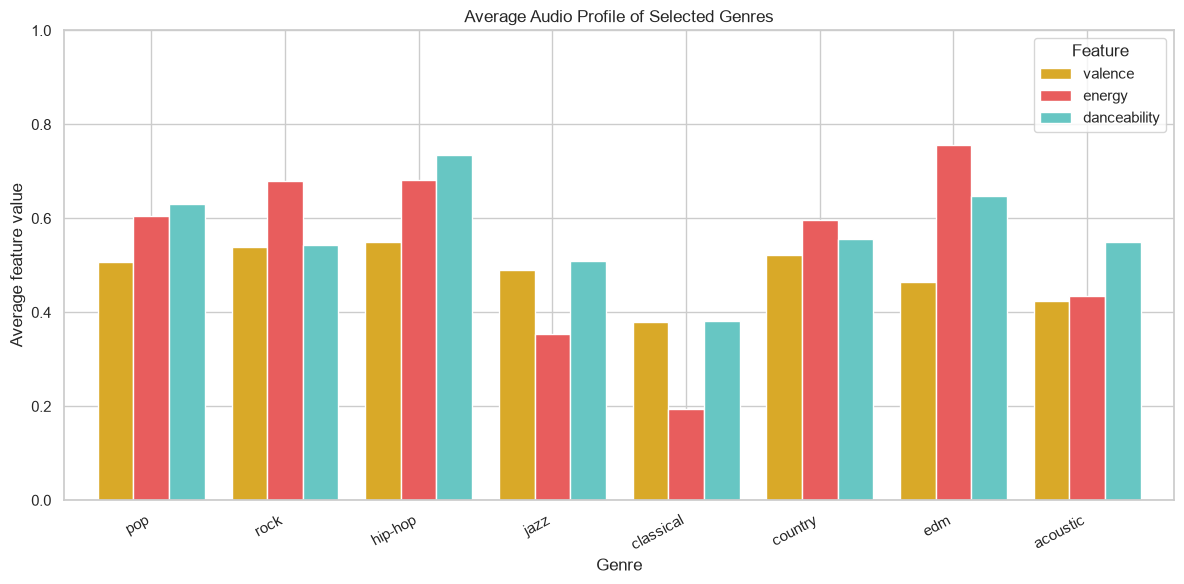

In [17]:
# Grouped bars make the three audio features easy to compare across genres.
genre_profile.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#D9A928', '#E85D5D', '#67C6C3'],
    width=0.8
)

plt.title('Average Audio Profile of Selected Genres')
plt.xlabel('Genre')
plt.ylabel('Average feature value')
plt.ylim(0, 1)
plt.xticks(rotation=28, ha='right')
plt.legend(title='Feature')
plt.tight_layout()
plt.savefig('reports/figures/03_eda/genre_audio_profiles.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/genre_audio_profiles.svg', bbox_inches='tight')
plt.show()

## 8. Danceability distribution by genre

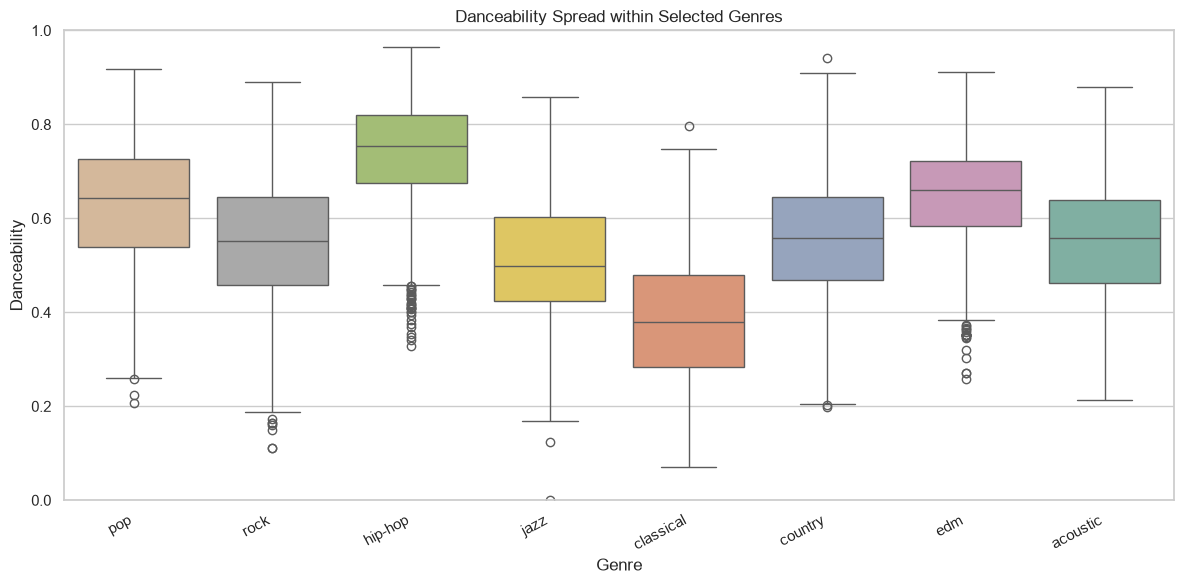

In [18]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=selected,
    x='track_genre',
    y='danceability',
    order=selected_genres,
    hue='track_genre',
    palette=genre_colors,
    legend=False
)

plt.title('Danceability Spread within Selected Genres')
plt.xlabel('Genre')
plt.ylabel('Danceability')
plt.ylim(0, 1)
plt.xticks(rotation=28, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/03_eda/genre_danceability_boxplot.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/genre_danceability_boxplot.svg', bbox_inches='tight')
plt.show()

## 9. Tempo distribution by genre

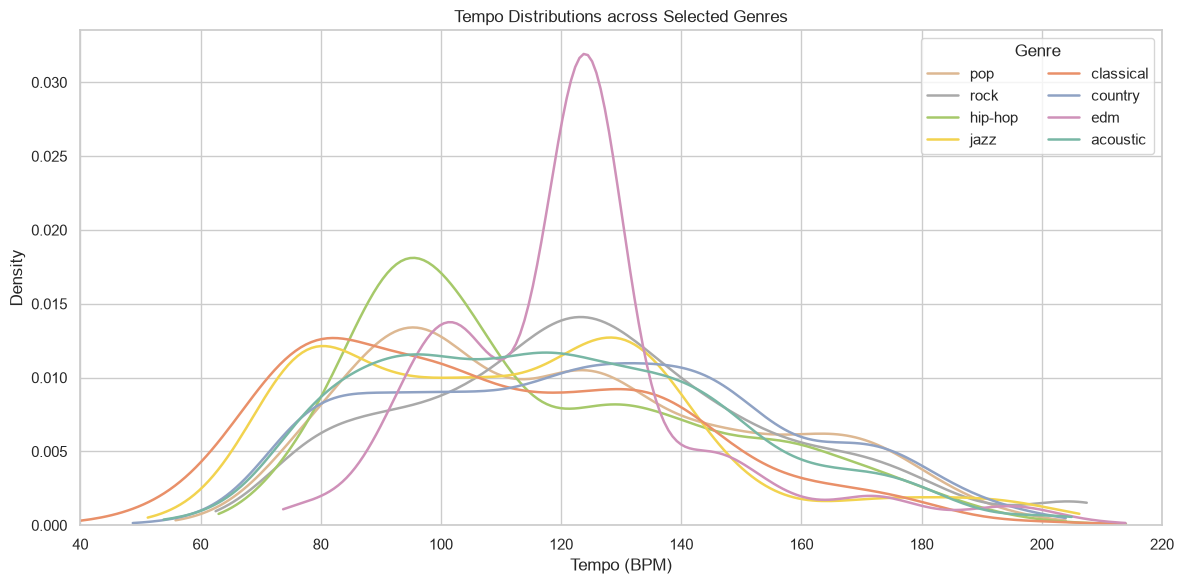

In [19]:
plt.figure(figsize=(12, 6))

# KDE curves make overlapping tempo distributions easier to compare than solid histograms.
for name in selected_genres:
    values = selected.loc[
        (selected['track_genre'] == name) & (selected['tempo'] > 0),
        'tempo'
    ]

    sns.kdeplot(
        values,
        label=name,
        linewidth=1.8,
        color=genre_colors[name],
        clip=(40, 220),
        cut=0
    )

plt.xlim(40, 220)
plt.title('Tempo Distributions across Selected Genres')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Density')
plt.legend(title='Genre', ncol=2)
plt.tight_layout()
plt.savefig('reports/figures/03_eda/genre_tempo_distributions.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/genre_tempo_distributions.svg', bbox_inches='tight')
plt.show()

## 10. Country / chart-scope mood profiles

For the full country dataset, this chart compares the **12 countries with the most chart observations**. `GLOBAL` is excluded from that country-to-country comparison because it represents World Top rather than a country.

The small development CSV supplied here contains only `GLOBAL` and `ZA`, so the notebook falls back to those two scopes when that sample is used. Once the full ~500 MB file is placed in `data/raw/` and Phases 1-3 are rerun, this same code automatically produces the richer 12-country chart.

In [20]:
# Prefer real country codes for comparison and leave GLOBAL out of the full-country chart.
country_only = country[country['country'] != 'GLOBAL'].copy()
country_counts = country_only['country'].value_counts()

if country_counts.index.nunique() >= 2:
    selected_countries = country_counts.head(12).index.tolist()
    country_plot_data = country_only[country_only['country'].isin(selected_countries)].copy()
else:
    # The 99-row sample only has one real country, so include GLOBAL as a useful fallback.
    selected_countries = country['country'].value_counts().head(12).index.tolist()
    country_plot_data = country[country['country'].isin(selected_countries)].copy()

print('Country scopes shown:', selected_countries)

Country scopes shown: ['DO', 'IT', 'NI', 'PL', 'HU', 'HN', 'SV', 'TH', 'EG', 'KZ', 'CZ', 'CR']


In [21]:
country_mood_plot = pd.crosstab(
    country_plot_data['country'],
    country_plot_data['mood_label'],
    normalize='index'
) * 100

country_mood_plot = country_mood_plot.reindex(columns=mood_order, fill_value=0)

# Order the bars by observation count so the most represented scope appears near the top.
plot_order = (
    country_plot_data['country']
    .value_counts()
    .reindex(country_mood_plot.index)
    .sort_values()
    .index
)

country_mood_plot = country_mood_plot.loc[plot_order]
country_mood_plot

mood_label,Euphoric,Peaceful,Aggressive,Melancholic
country,,,,
CR,58.993176,4.060217,29.460581,7.486026
CZ,38.757244,4.084222,47.899592,9.258942
EG,63.056822,3.988203,23.161071,9.793903
KZ,42.224204,6.278934,32.588046,18.908817
TH,43.671342,5.027262,38.417750,12.883646
HN,62.776901,3.473699,27.282079,6.467320
SV,62.955216,3.226802,27.220355,6.597627
HU,54.212530,4.245105,33.676234,7.866132
PL,46.814566,2.249349,44.266904,6.669181


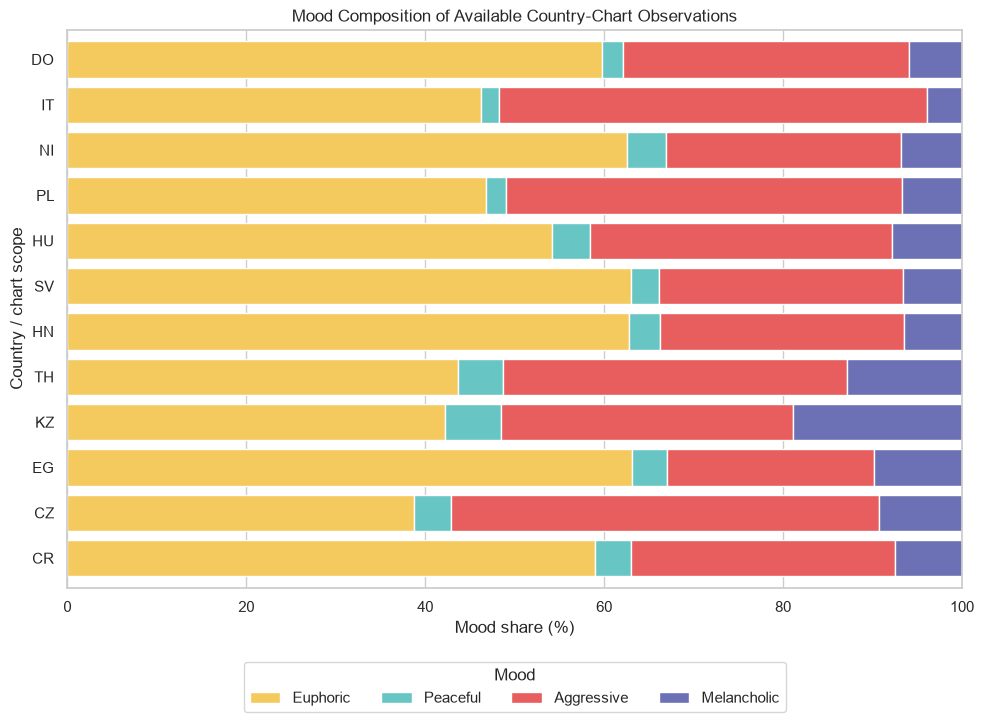

In [22]:
country_mood_plot.plot(
    kind='barh',
    stacked=True,
    figsize=(10, max(5, len(country_mood_plot) * 0.45 + 2)),
    color=[mood_colors[mood] for mood in mood_order],
    width=0.8
)

plt.title('Mood Composition of Available Country-Chart Observations')
plt.xlabel('Mood share (%)')
plt.ylabel('Country / chart scope')
plt.xlim(0, 100)
plt.legend(title='Mood', ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig('reports/figures/03_eda/country_mood_profiles.png', dpi=180, bbox_inches='tight')
plt.savefig('reports/figures/03_eda/country_mood_profiles.svg', bbox_inches='tight')
plt.show()

## 11. Save rich summary tables

The figures use selected categories for readability, but the exported tables keep the full analytical detail: all genres, every available country/chart scope, yearly mood percentages and descriptive statistics for all three datasets.

In [23]:
# Summary by all 114 genres.
genre_feature_summary = genre.groupby('track_genre').agg(
    track_count=('track_id', 'size'),
    unique_tracks=('track_id', 'nunique'),
    mean_danceability=('danceability', 'mean'),
    mean_energy=('energy', 'mean'),
    mean_loudness=('loudness', 'mean'),
    mean_speechiness=('speechiness', 'mean'),
    mean_acousticness=('acousticness', 'mean'),
    mean_instrumentalness=('instrumentalness', 'mean'),
    mean_liveness=('liveness', 'mean'),
    mean_valence=('valence', 'mean'),
    mean_tempo=('tempo', 'mean'),
    mean_popularity=('popularity', 'mean')
)

genre_mood = pd.crosstab(
    genre['track_genre'],
    genre['mood_label'],
    normalize='index'
) * 100

genre_mood = genre_mood.reindex(columns=mood_order, fill_value=0)
genre_mood.columns = ['pct_' + name.lower() for name in genre_mood.columns]
genre_feature_summary = genre_feature_summary.join(genre_mood)

genre_feature_summary.head()

,track_count,unique_tracks,mean_danceability,mean_energy,mean_loudness,mean_speechiness,mean_acousticness,mean_instrumentalness,mean_liveness,mean_valence,mean_tempo,mean_popularity,pct_euphoric,pct_peaceful,pct_aggressive,pct_melancholic
track_genre,,,,,,,,,,,,,,,,
acoustic,1000,1000,0.549593,0.435368,-9.447843,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624,42.483000,20.200000,13.400000,15.500000,50.900000
afrobeat,999,999,0.669408,0.702938,-7.789599,0.086622,0.270893,0.252876,0.184724,0.698475,119.242057,24.407407,72.772773,8.708709,13.213213,5.305305
alt-rock,999,999,0.534601,0.754027,-6.194009,0.055076,0.122168,0.054151,0.210340,0.518179,124.654403,33.896897,51.151151,2.402402,39.739740,6.706707
alternative,999,999,0.559963,0.719848,-6.076191,0.070134,0.147967,0.037501,0.201441,0.495158,122.207769,24.361361,44.344344,4.504505,40.740741,10.410410
ambient,999,999,0.367966,0.237257,-18.596266,0.041553,0.776701,0.675993,0.129298,0.167345,111.156413,44.208208,1.801802,1.501502,11.111111,85.585586


In [24]:
# Yearly summary with mood percentages.
yearly_summary = historical.groupby('year').agg(
    track_count=('track_id', 'size'),
    mean_valence=('valence', 'mean'),
    mean_energy=('energy', 'mean'),
    mean_danceability=('danceability', 'mean'),
    mean_popularity=('popularity', 'mean')
)

yearly_mood_table = yearly_moods.copy()
yearly_mood_table.columns = ['pct_' + name.lower() for name in yearly_mood_table.columns]
yearly_summary = yearly_summary.join(yearly_mood_table)

yearly_summary.head()

,track_count,mean_valence,mean_energy,mean_danceability,mean_popularity,pct_euphoric,pct_peaceful,pct_aggressive,pct_melancholic
year,,,,,,,,,
2000,100,0.628990,0.749500,0.65875,65.66,71.0,5.0,18.0,6.0
2001,100,0.653694,0.720960,0.67281,66.79,76.0,3.0,14.0,7.0
2002,100,0.574905,0.729480,0.65076,64.64,59.0,2.0,36.0,3.0
2003,100,0.600036,0.705130,0.66311,66.25,66.0,5.0,22.0,7.0
2004,100,0.598722,0.712545,0.66997,67.68,60.0,8.0,25.0,7.0


In [25]:
# Country summary keeps every available scope, not only the countries shown in the figure.
country_summary = country.groupby('country').agg(
    track_count=('track_id', 'size'),
    unique_tracks=('track_id', 'nunique'),
    mean_popularity=('popularity', 'mean'),
    mean_daily_rank=('daily_rank', 'mean'),
    mean_valence=('valence', 'mean'),
    mean_energy=('energy', 'mean'),
    mean_danceability=('danceability', 'mean')
)

country_mood_all = pd.crosstab(
    country['country'],
    country['mood_label'],
    normalize='index'
) * 100

country_mood_all = country_mood_all.reindex(columns=mood_order, fill_value=0)
country_mood_all.columns = ['pct_' + name.lower() for name in country_mood_all.columns]
country_summary = country_summary.join(country_mood_all)

country_summary.head()

,track_count,unique_tracks,mean_popularity,mean_daily_rank,mean_valence,mean_energy,mean_danceability,pct_euphoric,pct_peaceful,pct_aggressive,pct_melancholic
country,,,,,,,,,,,
AE,28866,828,86.436084,25.503083,0.496959,0.625375,0.638780,41.817363,4.493175,37.899259,15.790203
AR,29156,503,78.105433,25.496124,0.634396,0.681738,0.696413,70.997393,3.786528,20.795034,4.421045
AT,29024,1184,81.462169,25.500724,0.529844,0.661860,0.666443,49.693357,5.798649,32.900358,11.607635
AU,28965,663,87.536475,25.501640,0.511094,0.624872,0.629348,46.873813,4.847229,31.510444,16.768514
BE,29151,787,83.719975,25.494666,0.525835,0.650978,0.659427,50.416795,5.018696,31.944016,12.620493


In [26]:
descriptive_stats.to_csv('reports/tables/descriptive_statistics.csv', index=False)
correlation.to_csv('reports/tables/feature_correlation_matrix.csv')
genre_feature_summary.to_csv('reports/tables/genre_feature_summary.csv')
yearly_summary.to_csv('reports/tables/yearly_mood_summary.csv')
country_summary.to_csv('reports/tables/country_mood_summary.csv')

print('Saved 5 summary tables.')
print('Genres in genre summary:', len(genre_feature_summary))
print('Country/chart scopes in country summary:', len(country_summary))

Saved 5 summary tables.
Genres in genre summary: 114
Country/chart scopes in country summary: 73


## 12. Main findings from the supplied data

In [27]:
mood_percent = (historical['mood_label'].value_counts(normalize=True) * 100).round(2)

max_valence = yearly_trends.loc[yearly_trends['valence'].idxmax()]
min_valence = yearly_trends.loc[yearly_trends['valence'].idxmin()]
max_energy = yearly_trends.loc[yearly_trends['energy'].idxmax()]
min_energy = yearly_trends.loc[yearly_trends['energy'].idxmin()]

top_correlations = (
    correlation['popularity']
    .drop('popularity')
    .sort_values(key=abs, ascending=False)
    .head(5)
)

print('Historical years:', int(historical['year'].min()), '-', int(historical['year'].max()))
print('Genres represented:', genre['track_genre'].nunique())
print('Country/chart scopes represented:', country['country'].nunique())
print()
print('Top absolute correlations with popularity:')
print(top_correlations)

Historical years: 2000 - 2023
Genres represented: 114
Country/chart scopes represented: 73

Top absolute correlations with popularity:
instrumentalness   -0.094711
loudness            0.047371
speechiness        -0.045459
valence            -0.041109
danceability        0.034412
Name: popularity, dtype: float64


In [28]:
findings = f"""# Phase 3 Findings

- Historical analysis covers **{int(historical['year'].min())}-{int(historical['year'].max())}**.
- The genre dataset contains **{genre['track_genre'].nunique()} genre labels**.
- The eight visual comparison genres are: {', '.join(selected_genres)}.
- Mood distribution in the historical playlist:
{mood_percent.to_string()}
- Highest average valence: **{int(max_valence['year'])}** ({max_valence['valence']:.3f}).
- Lowest average valence: **{int(min_valence['year'])}** ({min_valence['valence']:.3f}).
- Highest average energy: **{int(max_energy['year'])}** ({max_energy['energy']:.3f}).
- Lowest average energy: **{int(min_energy['year'])}** ({min_energy['energy']:.3f}).
- Individual audio features show weak linear relationships with popularity in the supplied genre data.
- Country analysis currently contains **{country['country'].nunique()} chart scopes** in the supplied local file.
- With the full country CSV, the country figure automatically displays up to 12 of the most represented countries.
"""

with open('reports/eda/PHASE_03_FINDINGS.md', 'w') as f:
    f.write(findings)

eda_summary = {
    'phase': 3,
    'historical_years': [int(historical['year'].min()), int(historical['year'].max())],
    'genre_count': int(genre['track_genre'].nunique()),
    'selected_visual_genres': selected_genres,
    'country_scopes_available': sorted(country['country'].astype(str).unique().tolist()),
    'country_scopes_plotted': selected_countries,
    'country_sample_warning': bool(len(country) < 10000),
    'figures_created': 8,
    'tables_created': 5
}

with open('reports/eda/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=4)

print(findings)

# Phase 3 Findings

- Historical analysis covers **2000-2023**.
- The genre dataset contains **114 genre labels**.
- The eight visual comparison genres are: pop, rock, hip-hop, jazz, classical, country, edm, acoustic.
- Mood distribution in the historical playlist:
mood_label
Euphoric       52.46
Aggressive     33.96
Melancholic    10.04
Peaceful        3.54
- Highest average valence: **2001** (0.654).
- Lowest average valence: **2017** (0.461).
- Highest average energy: **2000** (0.750).
- Lowest average energy: **2020** (0.609).
- Individual audio features show weak linear relationships with popularity in the supplied genre data.
- Country analysis currently contains **73 chart scopes** in the supplied local file.
- With the full country CSV, the country figure automatically displays up to 12 of the most represented countries.

